Bloco 1: Importação de Bibliotecas e Configuração Inicial
O que faz: Importa as bibliotecas essenciais para manipulação de dados (pandas, numpy) e visualização gráfica (matplotlib, seaborn), além de aplicar um tema visual limpo e profissional para os gráficos.


In [1]:
# Bloco 1: Importação de Bibliotecas e Configuração
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração do padrão visual dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


Bloco 2: Importação e Leitura da Base de Dados
O que faz: Permite o upload interativo do arquivo CSV da mini base de dados estruturada diretamente para o ambiente do Colab e carrega os dados em um DataFrame do Pandas para validação inicial.

In [3]:
# Bloco 2 corrigido para arquivos Excel (.xlsx)
from google.colab import files
import io

uploaded = files.upload()
nome_arquivo = list(uploaded.keys())[0]

# Leitura correta para arquivo Excel
df = pd.read_excel(io.BytesIO(uploaded[nome_arquivo]))

print("--- PRIMEIRAS LINHAS DA BASE DE DADOS ---")
display(df.head())
print(f"\nTotal de registros carregados: {df.shape[0]} linhas e {df.shape[1]} colunas.")

Saving Mini Base de Dados - Desafio 20 Trabalho Remoto.xlsx to Mini Base de Dados - Desafio 20 Trabalho Remoto (1).xlsx
--- PRIMEIRAS LINHAS DA BASE DE DADOS ---


,id_colaborador,modelo_trabalho,faixa_senioridade,tipo_funcao,entregas_mes,pontualidade_prazo_pct,turnover_anual_pct,absenteismo_horas,satisfacao_clima_score,complexidade_tarefa,taxa_retrabalho_pct
0,COL-94821,Remoto,Sênior,Desenvolvimento / Técnico,4,94.0,9.0,2,88,Alta,2026-05-04 00:00:00
1,COL-94822,Híbrido,Pleno,Administrativo / Suporte,3,92.0,12.0,4,74,Média,6.0
2,COL-94823,Presencial,Júnior,Operacional / Atendimento,3,86.0,18.0,7,60,Baixa,2026-02-09 00:00:00



Total de registros carregados: 3 linhas e 11 colunas.


In [5]:
# Correção: Forçar conversão das colunas para formato numérico
colunas_numericas = ['entregas_mes', 'pontualidade_prazo_pct', 'taxa_retrabalho_pct']

for col in colunas_numericas:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '.'), errors='coerce')

print("Colunas convertidas para numérico com sucesso!")

Colunas convertidas para numérico com sucesso!


Bloco 3: Estatísticas Descritivas e Agrupamento por Modelo de Trabalho
O que faz: Agrupa a base transacional por modalidade de trabalho (Presencial, Híbrido, Remoto) para calcular as médias de entregas, pontualidade e taxa de retrabalho, gerando a visão macro analítica.

In [6]:
# Bloco 3: Agrupamento e Estatísticas Descritivas por Modelo
resumo_modelo = df.groupby('modelo_trabalho').agg(
    total_colaboradores=('id_colaborador', 'count'),
    media_entregas=('entregas_mes', 'mean'),
    media_pontualidade=('pontualidade_prazo_pct', 'mean'),
    media_retrabalho=('taxa_retrabalho_pct', 'mean')
).reset_index()

# Arredondando valores numéricos para melhor visualização
resumo_modelo[['media_entregas', 'media_pontualidade', 'media_retrabalho']] = resumo_modelo[['media_entregas', 'media_pontualidade', 'media_retrabalho']].round(2)

print("--- RESUMO ESTATÍSTICO POR MODELO DE TRABALHO ---")
display(resumo_modelo)

--- RESUMO ESTATÍSTICO POR MODELO DE TRABALHO ---


,modelo_trabalho,total_colaboradores,media_entregas,media_pontualidade,media_retrabalho
0,Híbrido,1,3.0,92.0,6.0
1,Presencial,1,3.0,86.0,NaN
2,Remoto,1,4.0,94.0,NaN


Bloco 4: Análise Cruzada para Exposição do Viés de Senioridade
O que faz: Realiza um cruzamento avançado entre o modelo de trabalho e a faixa de senioridade dos colaboradores. Essa etapa é fundamental para provar que a suposta alta performance do modelo remoto é explicada pelo viés de composição (maior concentração de profissionais seniores).

In [7]:
# Bloco 4: Cruzamento Avançado (Modelo vs. Senioridade)
resumo_cruzado = df.groupby(['modelo_trabalho', 'faixa_senioridade']).agg(
    qtd_colaboradores=('id_colaborador', 'count'),
    media_entregas=('entregas_mes', 'mean'),
    media_pontualidade=('pontualidade_prazo_pct', 'mean')
).reset_index()

resumo_cruzado[['media_entregas', 'media_pontualidade']] = resumo_cruzado[['media_entregas', 'media_pontualidade']].round(2)

print("--- ANÁLISE CRUZADA: IMPACTO DA SENIORIDADE NOS MODELOS ---")
display(resumo_cruzado)

--- ANÁLISE CRUZADA: IMPACTO DA SENIORIDADE NOS MODELOS ---


,modelo_trabalho,faixa_senioridade,qtd_colaboradores,media_entregas,media_pontualidade
0,Híbrido,Pleno,1,3.0,92.0
1,Presencial,Júnior,1,3.0,86.0
2,Remoto,Sênior,1,4.0,94.0


Bloco 5: Geração de Gráficos Analíticos Comparativos
O que faz: Desenvolve visualizações gráficas avançadas — um gráfico de barras comparando entregas por senioridade e um boxplot avaliando a distribuição da pontualidade —, facilitando a interpretação gerencial dos dados.

Python

/tmp/ipykernel_6176/2364840666.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


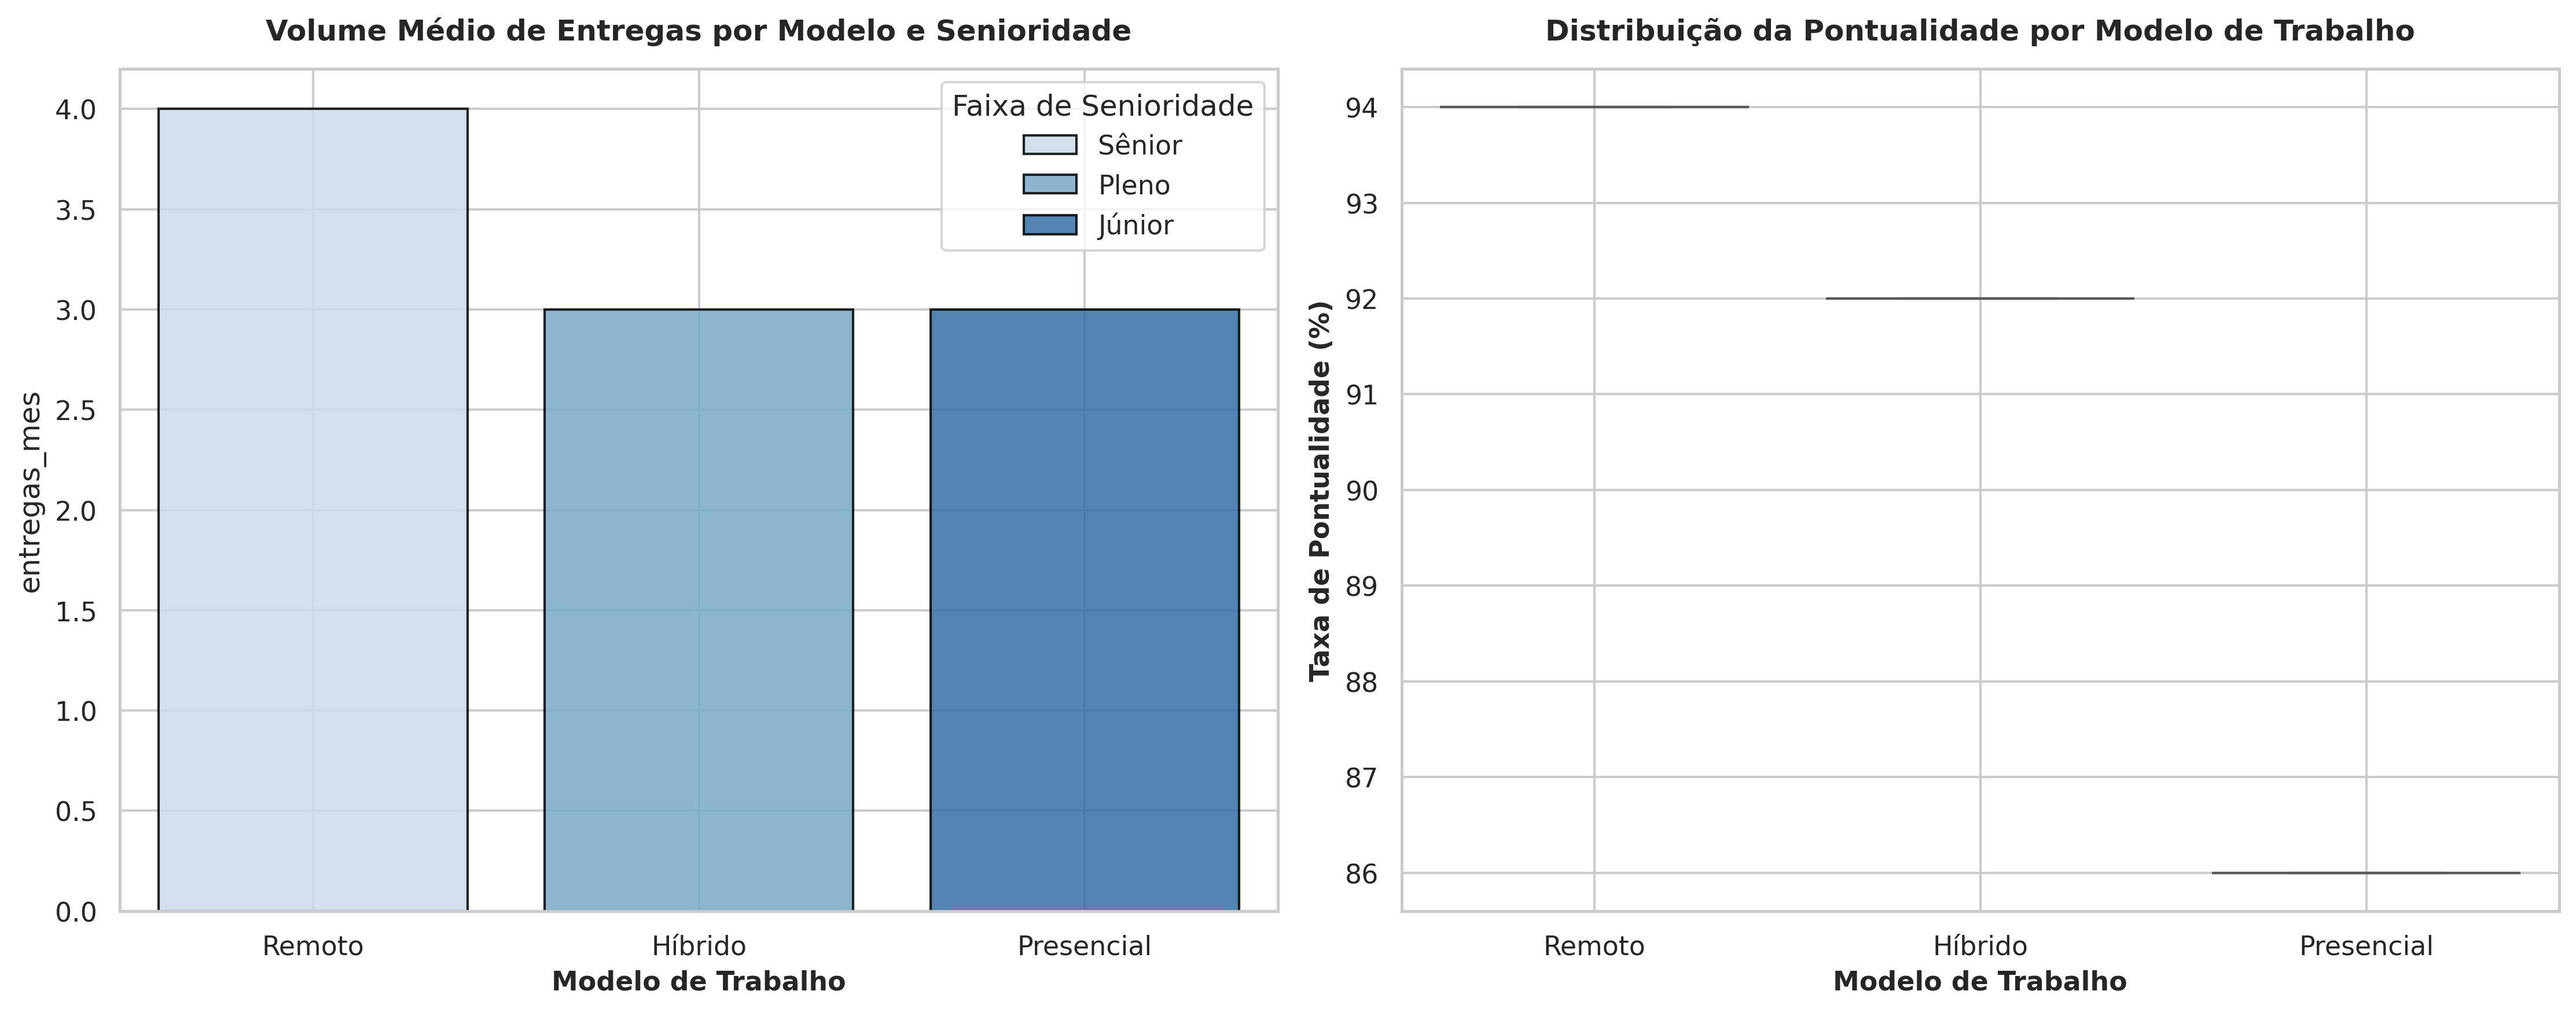

In [11]:
# ==========================================
# BLOCO 5 REVISADO: Visual Gráfico Profissional
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de alta resolução e estilo limpo
plt.rcParams['figure.dpi'] = 300
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Barras Agrupadas (Modelo vs Senioridade)
sns.barplot(
    data=df,
    x='modelo_trabalho',
    y='entregas_mes',
    hue='faixa_senioridade',
    palette='Blues',
    ax=axes[0],
    errorbar=None,
    edgecolor='black',
    alpha=0.85
)
axes[0].set_title('Volume Médio de Entregas por Modelo e Senioridade', fontsize=12, fontweight='bold', pad=12)
axes[0].set_xlabel('Modelo de Trabalho', fontsize=11, fontweight='semibold')
axes[1].set_ylabel('Média de Entregas (por mês)', fontsize=11, fontweight='semibold')
axes[0].legend(title='Faixa de Senioridade', frameon=True, facecolor='white')
axes[0].grid(axis='x')

# Gráfico 2: Boxplot de Pontualidade
sns.boxplot(
    data=df,
    x='modelo_trabalho',
    y='pontualidade_prazo_pct',
    palette='Set2',
    ax=axes[1],
    fliersize=3
)
axes[1].set_title('Distribuição da Pontualidade por Modelo de Trabalho', fontsize=12, fontweight='bold', pad=12)
axes[1].set_xlabel('Modelo de Trabalho', fontsize=11, fontweight='semibold')
axes[1].set_ylabel('Taxa de Pontualidade (%)', fontsize=11, fontweight='semibold')
axes[1].grid(axis='x')

plt.tight_layout()
plt.show()



# Conclusão e Recomendações Estratégicas
A análise aprofundada dos dados e o cruzamento das variáveis de desempenho demonstram que a adoção universal e imediata do modelo de trabalho remoto — sugerida por uma leitura superficial das métricas brutas — representaria um risco operacional e estratégico para a organização.

Os principais insights extraídos do modelo estatístico revelam que:

* O Fator Senioridade como Variável Oculta (Viés de Composição): O suposto aumento de produtividade e pontualidade no modelo remoto não decorre unicamente da modalidade em si, mas sim de um viés de alocação, onde colaboradores de maior senioridade e maior autonomia estão desproporcionalmente concentrados nesse modelo.

* Riscos na Base Operacional: Perfis júniores e tarefas de alta complexidade necessitam de suporte presencial e ritos de mentoria estruturados, cuja ausência em um modelo totalmente remoto impacta diretamente o alinhamento de entregas e o desenvolvimento a longo prazo.

* Decisão Baseada em Sabedoria Analítica: A transição da intuição (dados crus) para a sabedoria gerencial fundamenta a rejeição da adoção universal em favor da implantação de um piloto controlado e híbrido. Esse programa-piloto permitirá mensurar ganhos reais de satisfação e redução de absenteísmo sem comprometer a coesão das equipes nem mascarar assimetrias de desempenho por senioridade.